In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Graded Assignment 3/Dataset_For_Stats.xlsx'
all_sheets = pd.read_excel(file_path, sheet_name=None)

healthy = all_sheets['Healthy']
recovered = all_sheets['Recovered']
disease = all_sheets['Disease']

groups = {
    "Healthy": healthy,
    "Disease": disease,
    "Recovered": recovered
}

### 1. Perform a normality test (e.g., Shapiro–Wilk test) for each feature in the dataset, separately for the three groups: Healthy, Disease, and Recovered.
- Use a significance level (α) of 0.05.
- Specifically compare feature1, feature2, and feature4 to check for distribution similarity between groups.
- Visualize the comparison using appropriate plots (e.g., histograms, Q–Q plots, or box plots)

Test used: Shapiro–Wilk test

Significance level: 𝛼 = 0.05

Hypotheses:
- H₀: Feature values are normally distributed
- H₁: Feature values are not normally distributed

Decision rule:
- If p ≥ 0.05 → Fail to reject H₀ (approximately normal)
- If p < 0.05 → Reject H₀ (non-normal)

In [3]:
from scipy.stats import shapiro, probplot

normality_results = {}
alpha = 0.05

for group_name, data in groups.items():
    print(f"\n{group_name} Group:")
    print("-" * 60)
    normality_results[group_name] = {}

    for col in data.columns:
        stat, p_value = shapiro(data[col])
        is_normal = "Normally distributed" if p_value > alpha else "Not Normally distributed"
        normality_results[group_name][col] = {
            'statistic': stat,
            'p_value': p_value,
            'is_normal': is_normal
        }
        print(f"{col}: Statistic={stat:.4f}, p-value={p_value:.4f} -> {is_normal}")


Healthy Group:
------------------------------------------------------------
Feature 1: Statistic=0.9844, p-value=0.0886 -> Normally distributed
Feature 2: Statistic=0.9575, p-value=0.0001 -> Not Normally distributed
Feature 3: Statistic=0.9455, p-value=0.0000 -> Not Normally distributed
Feature 4: Statistic=0.9733, p-value=0.0051 -> Not Normally distributed
Feature 5: Statistic=0.9830, p-value=0.0617 -> Normally distributed
Feature 6: Statistic=0.9955, p-value=0.9303 -> Normally distributed

Disease Group:
------------------------------------------------------------
Feature 1: Statistic=0.9951, p-value=0.8982 -> Normally distributed
Feature 2: Statistic=0.9823, p-value=0.0508 -> Normally distributed
Feature 3: Statistic=0.9734, p-value=0.0052 -> Not Normally distributed
Feature 4: Statistic=0.9293, p-value=0.0000 -> Not Normally distributed
Feature 5: Statistic=0.9934, p-value=0.7258 -> Normally distributed
Feature 6: Statistic=0.9847, p-value=0.0946 -> Normally distributed

Recovered

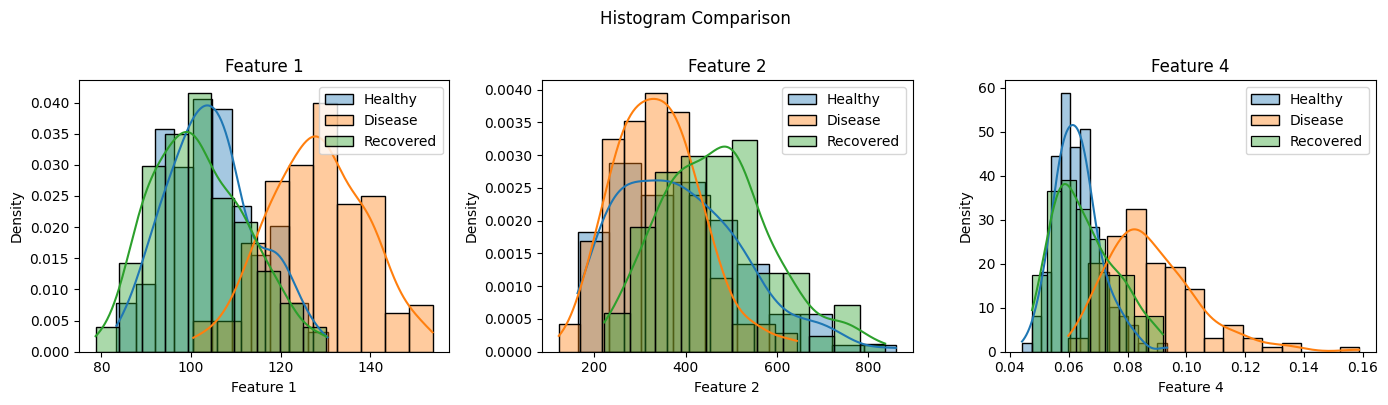

In [4]:
features = ['Feature 1','Feature 2','Feature 4']

plt.figure(figsize=(14, 4))
for i, feature in enumerate(features, 1):
    plt.subplot(1, len(features), i)
    for group_name, df in groups.items():
        sns.histplot(df[feature], label=group_name, kde=True, stat="density", alpha=0.4)

    plt.title(f"{feature}")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend()

plt.suptitle("Histogram Comparison", y=1)
plt.tight_layout()
plt.show()

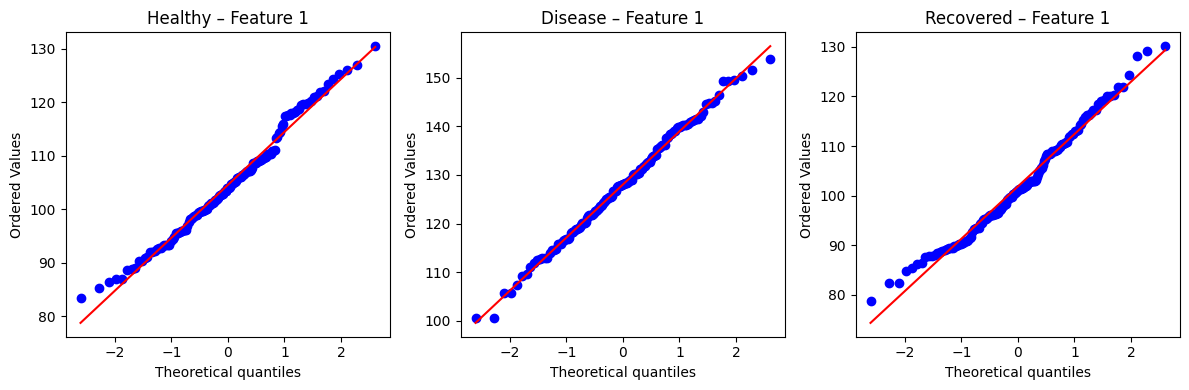

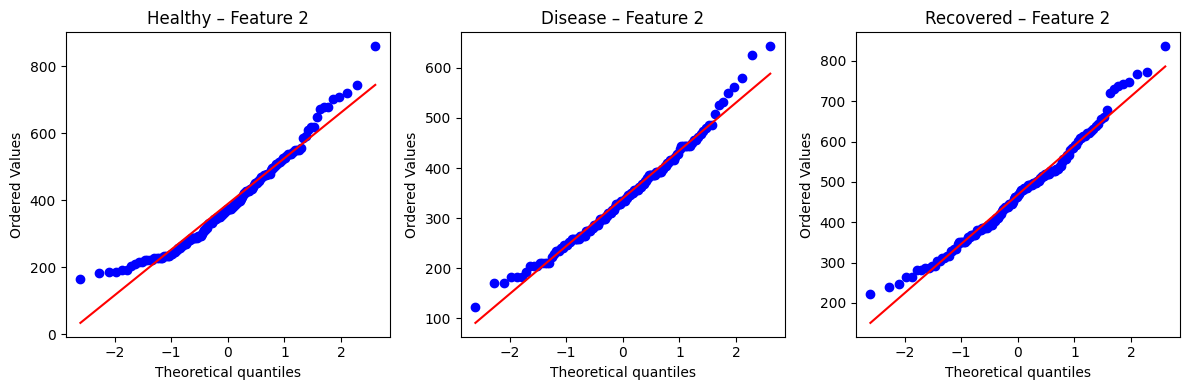

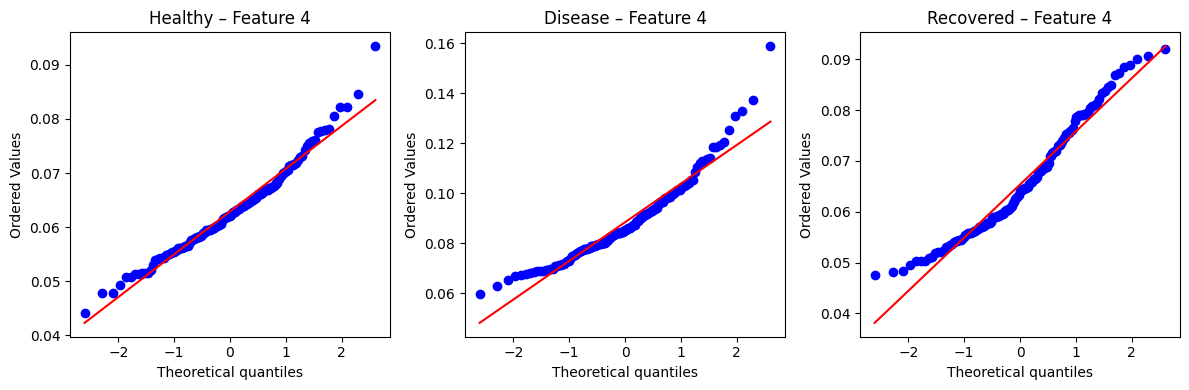

In [5]:
for feature in features:
    plt.figure(figsize=(12, 4))
    for i, (group_name, df) in enumerate(groups.items(), 1):
        plt.subplot(1, 3, i)
        probplot(df[feature], plot=plt)
        plt.title(f"{group_name} – {feature}")
    plt.tight_layout()
    plt.show()

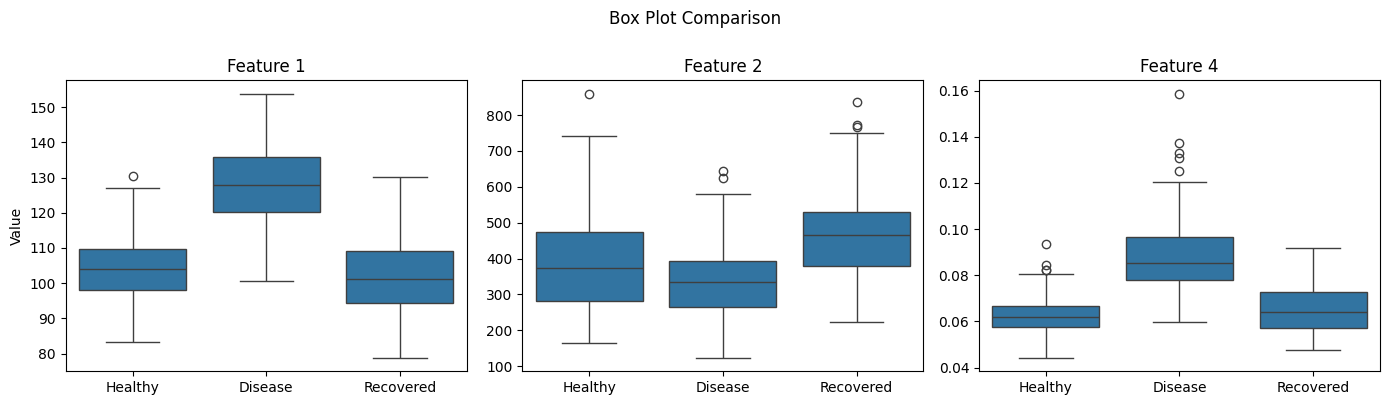

In [6]:
plt.figure(figsize=(14, 4))

for i, feature in enumerate(features, 1):
    combined = pd.concat([
        healthy[[feature]].assign(Group="Healthy"),
        disease[[feature]].assign(Group="Disease"),
        recovered[[feature]].assign(Group="Recovered")
    ])

    plt.subplot(1, len(features), i)
    sns.boxplot(x="Group", y=feature, data=combined)
    plt.title(feature)
    plt.xlabel("")
    plt.ylabel("Value" if i == 1 else "")

plt.suptitle("Box Plot Comparison", y=1)
plt.tight_layout()
plt.show()


### 2. Group Equality Testing
For feature1, feature2, and feature4, test the null hypothesis that the distributions of the selected features are equal across the groups.
- State the null and alternative hypotheses clearly.
- Use an appropriate statistical test (parametric or non-parametric, depending on normality results).


Answer:

For each feature (feature1, feature2, feature4):

**Null hypothesis (H0)**: The distributions (or means, if parametric) of the feature are equal across the Healthy, Disease, and Recovered groups.

**Alternative hypothesis (H1)**: At least one group differs from the others in distribution (or mean).

In [7]:
from scipy.stats import kruskal, f_oneway
features_to_test = ['Feature 1', 'Feature 2', 'Feature 4']

for feature in features_to_test:
    print(f"\n\nTesting: {feature}")
    print(f"{'-'*80}")

    healthy_data = groups['Healthy'][feature]
    disease_data = groups['Disease'][feature]
    recovered_data = groups['Recovered'][feature]

    all_normal = all([
        normality_results['Healthy'][feature]['is_normal'] == 'Normally distributed',
        normality_results['Disease'][feature]['is_normal'] == 'Normally distributed',
        normality_results['Recovered'][feature]['is_normal'] == 'Normally distributed'
    ])


    if all_normal:
        print(f"\nTest Used: One-way ANOVA (Parametric)")
        print(f"Reason: All groups are normally distributed")

        stat, p_value = f_oneway(healthy_data, disease_data, recovered_data)
        test_name = "F-statistic"
    else:
        print(f"\nTest Used: Kruskal-Wallis H-test (Non-parametric)")
        print(f"Reason: Not all groups are normally distributed")

        stat, p_value = kruskal(healthy_data, disease_data, recovered_data)
        test_name = "H-statistic"

    print(f"\nResults:")
    print(f"  {test_name}: {stat:.4f}")
    print(f"  p-value: {p_value:.6f}")
    print(f"  Significance level (α): {alpha}")

    if p_value < alpha:
        print(f"  Decision: Reject H0")
        print(f"  Conclusion: There is significant evidence that the distributions differ across groups")
    else:
        print(f"  Decision: Fail to reject H0")
        print(f"  Conclusion: There is no significant evidence that the distributions differ across groups")



Testing: Feature 1
--------------------------------------------------------------------------------

Test Used: Kruskal-Wallis H-test (Non-parametric)
Reason: Not all groups are normally distributed

Results:
  H-statistic: 242.5462
  p-value: 0.000000
  Significance level (α): 0.05
  Decision: Reject H0
  Conclusion: There is significant evidence that the distributions differ across groups


Testing: Feature 2
--------------------------------------------------------------------------------

Test Used: Kruskal-Wallis H-test (Non-parametric)
Reason: Not all groups are normally distributed

Results:
  H-statistic: 77.7309
  p-value: 0.000000
  Significance level (α): 0.05
  Decision: Reject H0
  Conclusion: There is significant evidence that the distributions differ across groups


Testing: Feature 4
--------------------------------------------------------------------------------

Test Used: Kruskal-Wallis H-test (Non-parametric)
Reason: Not all groups are normally distributed

Results

### 3. One-way ANOVA on All Features
Conduct hypothesis testing to compare all features among the three groups (Healthy, Disease, Recovered) using One-way ANOVA at three different significance levels:
- α = 0.05
- α = 0.001
- α = 0.0001

Report which features show statistically significant differences at each
significance level.


In [8]:
from scipy.stats import f_oneway

alpha_levels = [0.05, 0.001, 0.0001]
all_features = ['Feature 1', 'Feature 2', 'Feature 3', 'Feature 4', 'Feature 5', 'Feature 6']
anova_results = {}

for feature in all_features:
    healthy_data = groups['Healthy'][feature]
    disease_data = groups['Disease'][feature]
    recovered_data = groups['Recovered'][feature]

    stat, p_value = f_oneway(healthy_data, disease_data, recovered_data)
    anova_results[feature] = {'F-statistic': stat, 'p-value': p_value}


for alpha_level in alpha_levels:
    print(f"\n\nSignificance Level (α) = {alpha_level}")
    print(f"{'='*80}")

    significant_features = []

    for feature, result in anova_results.items():
        is_significant = result['p-value'] < alpha_level
        status = "Significant difference" if is_significant else "Not Significant"

        print(f"{feature}:")
        print(f"  F-statistic: {result['F-statistic']:.4f}")
        print(f"  p-value: {round(result['p-value'], 4):.4f}")
        print(f"  Result: {status}")
        print()

        if is_significant:
            significant_features.append(feature)

    print(f"Significant features at α = {alpha_level} : {significant_features}")



Significance Level (α) = 0.05
Feature 1:
  F-statistic: 286.4765
  p-value: 0.0000
  Result: Significant difference

Feature 2:
  F-statistic: 44.1421
  p-value: 0.0000
  Result: Significant difference

Feature 3:
  F-statistic: 202.5775
  p-value: 0.0000
  Result: Significant difference

Feature 4:
  F-statistic: 209.7673
  p-value: 0.0000
  Result: Significant difference

Feature 5:
  F-statistic: 238.8860
  p-value: 0.0000
  Result: Significant difference

Feature 6:
  F-statistic: 289.4227
  p-value: 0.0000
  Result: Significant difference

Significant features at α = 0.05 : ['Feature 1', 'Feature 2', 'Feature 3', 'Feature 4', 'Feature 5', 'Feature 6']


Significance Level (α) = 0.001
Feature 1:
  F-statistic: 286.4765
  p-value: 0.0000
  Result: Significant difference

Feature 2:
  F-statistic: 44.1421
  p-value: 0.0000
  Result: Significant difference

Feature 3:
  F-statistic: 202.5775
  p-value: 0.0000
  Result: Significant difference

Feature 4:
  F-statistic: 209.7673
  p-v